In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Configurazione stile grafico
sns.set_theme(style="whitegrid")

# 1. Caricamente dati
data = load_iris()
X = data.data
y = data.target

# 2 Standardizzazione (Fondamentale)
# StandardScaler sottrae la media e divide per la deviazione standard
X_scaled = StandardScaler().fit_transform(X)

# 3. Applicazione PCA
pca = PCA(n_components=2)  # Vogliamo passare da 4D a 2D
X_pca = pca.fit_transform(X_scaled)

# Creazione DataFrame per visualizzazione
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca['Target'] = data.target_names[y]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1',y='PC2', hue='Target',palette='viridis', s=70)
plt.title(f"PCA di Iris; Varianza Totale Spiegata {np.sum(pca.explained_variance_ratio_):.2f}")
plt.show()

print(f"Varianza PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza PC2: {pca.explained_variance_ratio_[1]:.2f}")

In [ ]:
pca_full = PCA().fit(X_scaled)
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o',linestyle='--')
plt.xlabel('Numero di componenti')
plt.ylabel('Varianza Spiegata Cumulativa')
plt.axhline(y=0.95, color='r', linestyle='-')   # Linead del 95%
plt.show()

PCA for image Compression

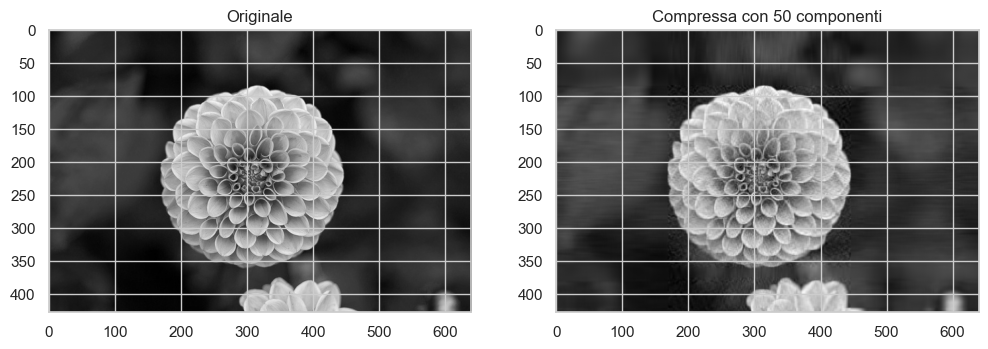

In [12]:
from matplotlib.image import imread
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Carica l'immagine e trasformala in scala di grigi
img_raw = load_sample_image('flower.jpg')
img_gray = img_raw.mean(axis=2)     # Media dei canali RGB per avere il grigio

# 2. Applica PCA mantenendo solo 50 componenti su (es.) 800
n_comp = 50
pca = PCA(n_components=n_comp)
img_transformed = pca.fit_transform(img_gray)

# 3. Ricostruisci l'immagine proiettandola indietro nello spazio originale
img_reconstructed = pca.inverse_transform(img_transformed)

# Visualizzazione
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray'); plt.title("Originale")
plt.subplot(1, 2, 2)
plt.imshow(img_reconstructed, cmap='gray')
plt.title(f"Compressa con {n_comp} componenti")
plt.show()
